### Setup: Read CSV Files

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

accounts = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/accounts.csv')
cards = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/cards.csv')
loan = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/loans.csv')
loan_payment = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/loan_payments.csv')
employees = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/employees.csv')
support_tickets = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/support_tickets.csv')
branches = pd.read_csv('/Users/rohananjutgi/Desktop/new_folder/banking-transactions-dataset/versions/1/branches.csv')

accounts = accounts[accounts['status'] != 'Closed']
display(accounts)

,account_id,customer_id,branch_id,account_type,balance,open_date,status
0,1,11749,141,Current,95902.00,2019-10-20,Active
1,2,47716,43,Current,13261.61,2026-02-03,Active
2,3,56143,90,Savings,26495.92,2020-10-19,Active
3,4,29193,113,Salary,74682.72,2012-02-22,Active
4,5,49907,28,Current,40419.01,2007-01-03,Active
...,...,...,...,...,...,...,...
94994,94995,15252,46,NRI,44848.71,2006-01-24,Active
94996,94997,50856,12,Current,39854.55,2011-10-21,Active
94997,94998,8593,68,Current,9310.24,2021-03-22,Active
94998,94999,49233,107,Fixed Deposit,13110.16,2009-10-16,Active


## Goal
<br>
To analyze how to loan market is affecting the progress of the Bank's OKR's. 

### Questions to ask
- How are loan amounts trending overtime? 
- How are our resources being utilized between departments?  
- How are users using our support tickets system?   
- Top 10 performing branches by loans offered 



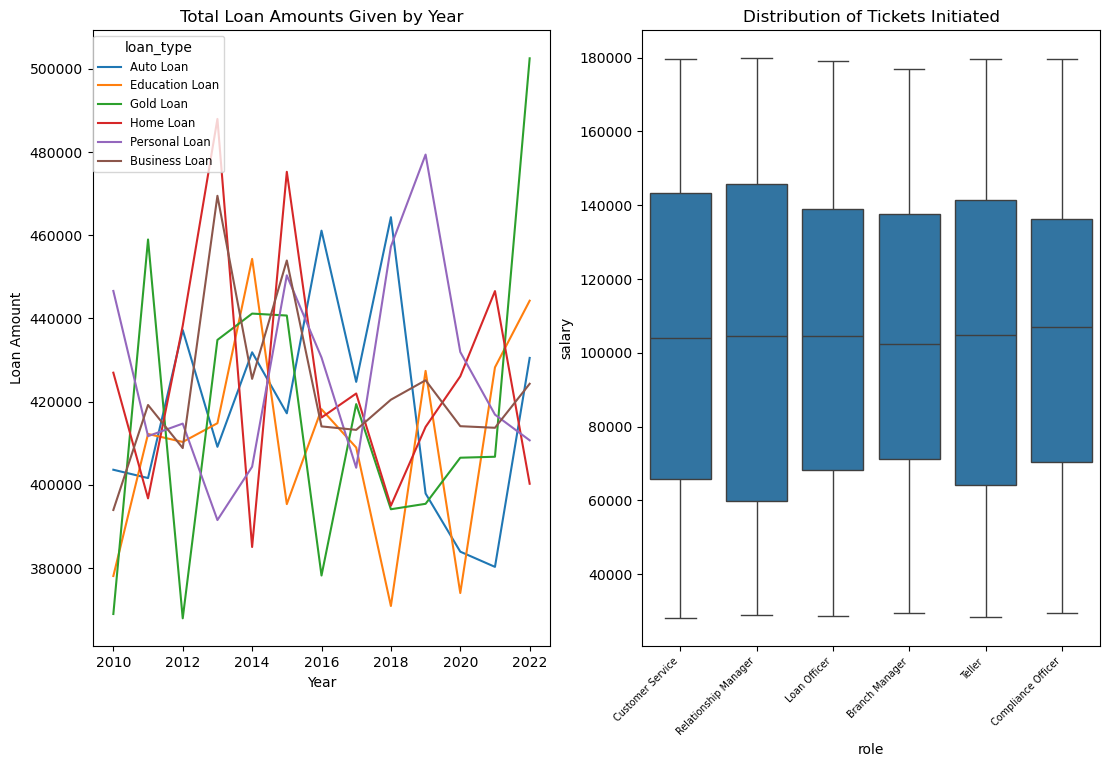

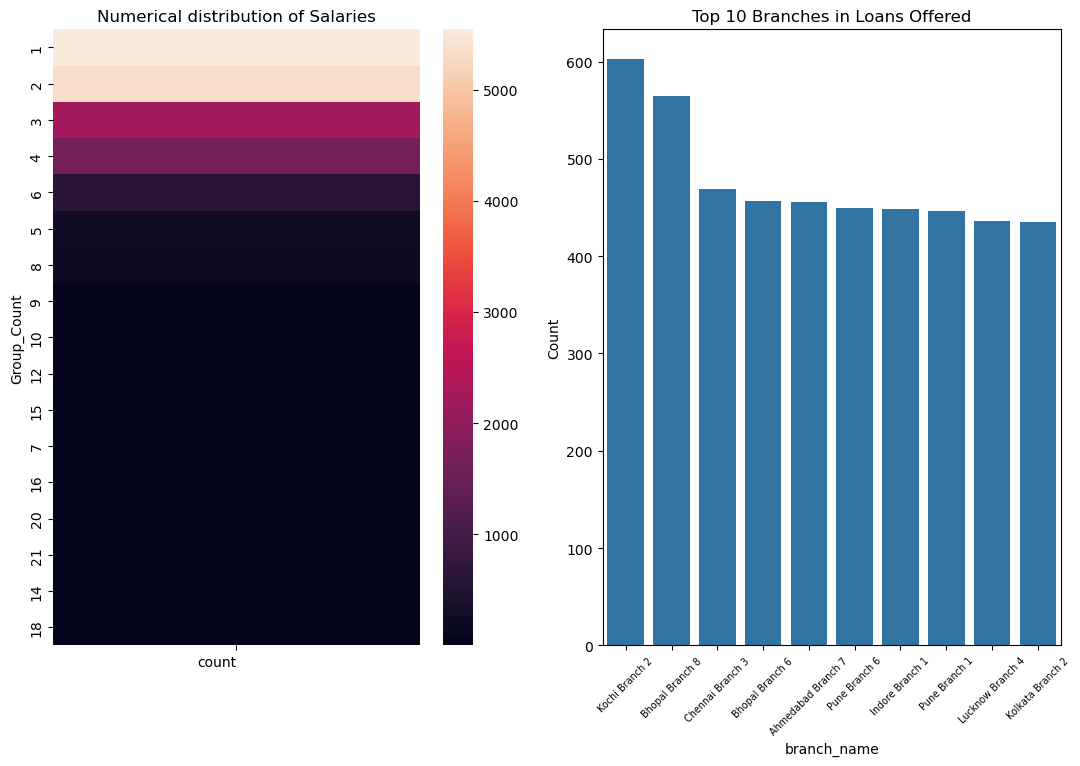

In [48]:
loan['start_date'] = pd.to_datetime(loan['start_date'])
loan['year'] = loan[loan['start_date'].dt.year <2023 ]['start_date'].dt.year#strftime("%Y-%m")
df3 = loan.groupby('year')['loan_amount'].agg('sum')

df4 = employees.groupby('role')['salary']

fig, axs = plt.subplots(1,2, figsize = (13,8))
fig2, axs2 = plt.subplots(1,2, figsize = (13,8))
#axs[0,0].yaxis.set_major_formatter('^\d{1,3},\d{3},\d{3}$')
axs[0].set_title('Total Loan Amounts Given by Year')

#lineplot and boxplot
sns.lineplot(data = loan, x = 'year', y= 'loan_amount', hue = 'loan_type', ax = axs[0], errorbar = None)
sns.move_legend(axs[0], "upper right", fontsize = 'small', bbox_to_anchor=(.3, 1))
sns.boxplot(data = employees, x = 'role', y = 'salary', ax = axs[1])

#aetting ax labels
axs[0].set_ylabel('Loan Amount')
axs[0].set_xlabel('Year')
axs[1].tick_params(axis='x', labelrotation=45, labelsize = 'x-small')
for label in axs[1].get_xticklabels():
    label.set_horizontalalignment('right')
axs[1].set_title('Numerical distribution of Salaries')

#Heatmap analyzing the number of tickets intiated
accounts_support = pd.merge(accounts, support_tickets, on = 'customer_id')
accounts_support['Group_Count'] = accounts_support.groupby('customer_id')['ticket_id'].transform('count')
account_support_distinct = accounts_support.drop_duplicates(subset = ['customer_id'], keep = 'first')

df4 = account_support_distinct[['Group_Count']].value_counts().to_frame()

sns.heatmap(data = df4, ax = axs2[0])
axs[1].set_title('Distribution of Tickets Initiated')

#  Top 10 in most loans being offered? 
loan_branches = pd.merge(loan, branches, on = 'branch_id')
loan_branches = loan_branches.groupby('branch_name').size().reset_index()

loan_branches.columns = loan_branches.columns.str.strip()
loan_branches = loan_branches.rename(columns ={np.nan:"Count"})
loan_branches = loan_branches.sort_values(by = 'Count', ascending=False).head(10)
sns.barplot(data =loan_branches, x = 'branch_name', y = 'Count')

axs2[1].tick_params(axis='x', labelrotation=45, labelsize = 'x-small')
for label in axs2[0].get_xticklabels():
    label.set_horizontalalignment('right')
axs2[0].set_title('Numerical distribution of Salaries')

axs2[1].set_title('Top 10 Branches in Loans Offered')
plt.show()